In [1]:
import torch
import time
import matplotlib.pyplot as plt
from torchscan import summary

from campolina.model import UNet, Default

In [2]:
torch.set_float32_matmul_precision('high')

compile = lambda m: torch.compile(m, fullgraph=True, mode="reduce-overhead")

In [3]:
def benchmark(model, input_tensor, n_warmup=10, n_runs=100):
    model.eval()

    # warmup
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(input_tensor)

    total_time = 0

    for _ in range(n_runs):

        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)

        with torch.no_grad():
            start.record()
            o = model(input_tensor)
            end.record()
            torch.cuda.synchronize()
            
            total_time += start.elapsed_time(end)

    return total_time / n_runs

### Compute Inference Times

In [4]:
default = Default.make_default().cuda()
default_compiled = compile(default)

unet = UNet.make_default().cuda()
unet_compiled = compile(unet)

times_default  = []
times_default_compiled  = []

times_unet = []
times_unet_compiled = []

batch_size = 64

lengths = [2**i for i in range(8, 14+1)]

for length in lengths:
    print(f'length = {length}')

    input = torch.randn(batch_size, 4, length, device='cuda:0')

    for model, times in [
        (default, times_default), 
        (default_compiled, times_default_compiled), 
        (unet, times_unet),
        (unet_compiled, times_unet_compiled)
    ]:
        time = benchmark(model, input)
        times.append(time)
        print(f'{time:.2f}')
    
    print()

length = 256
0.85
0.72
2.64
1.15

length = 512
1.41
1.26
4.03
1.79

length = 1024
3.58
3.21
7.24
4.39

length = 2048
7.61
6.82
14.24
8.73

length = 4096
15.55
12.93
29.02
18.13

length = 8192
32.78
27.35
58.36
36.66

length = 16384
66.54
54.98
115.74
74.70



### Plot Comparison

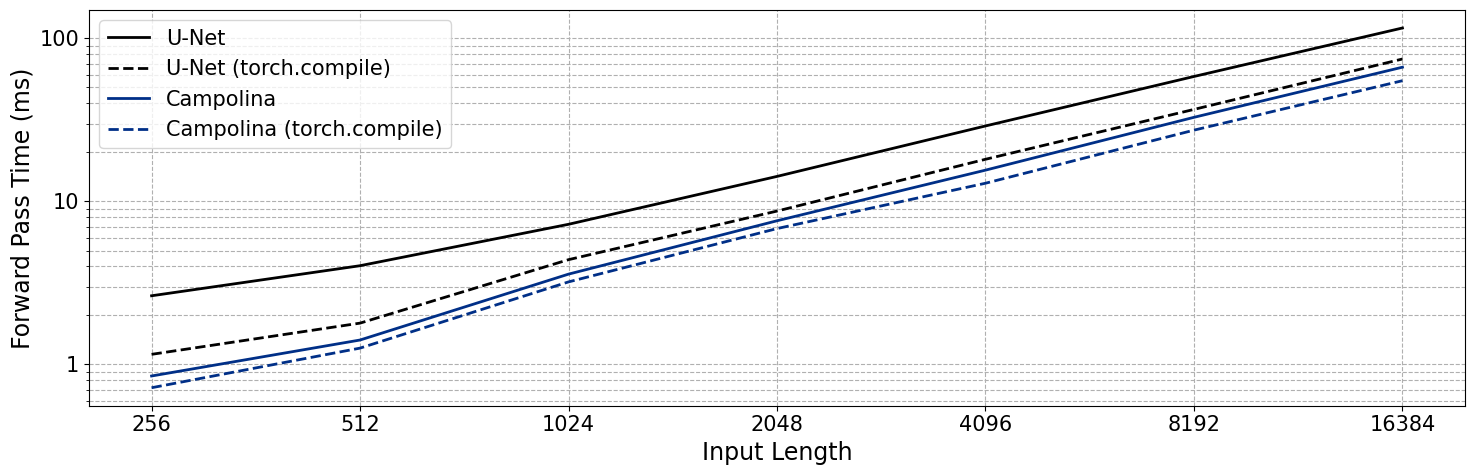

In [5]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({'font.size': 15})
fig = plt.figure(figsize=(15, 5))
plt.plot(times_unet, label='U-Net', color='black', linewidth=2)
plt.plot(times_unet_compiled, label='U-Net (torch.compile)', color='black', linestyle='--', linewidth=2)
plt.plot(times_default, label='Campolina', color='#002F87', linewidth=2)
plt.plot(times_default_compiled, label='Campolina (torch.compile)', color='#002F87', linestyle='--', linewidth=2)
plt.xlabel('Input Length', fontsize=17)
plt.ylabel('Forward Pass Time (ms)', fontsize=17)
plt.yscale('log', base=10)

def format_x(value, tick_number): return f"{2**(8+value):.0f}" 
def format_y(value, tick_number): return f"{value:.0f}" 

plt.grid(True, which="both", ls="--")
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_x))
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y))

plt.legend()
plt.tight_layout()
plt.show()
fig.savefig('benchmark.png', dpi=300)